**Recreating Dataset**

In [ ]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# importing datasets
raw_df1 = pd.read_csv('../data/raw/3bcbe6_50a01871fe52483faaa820ce3fe0b4fb.csv')
raw_df2 = pd.read_csv('../data/raw/3bcbe6_b36b00eb485946dfb14edc2a41324071.csv')

In [ ]:
raw_df1.head()

In [ ]:
raw_df2.head()

In [ ]:
# finding columns of dataset and cleaning column names for dataset1
cols1 = None
for col in raw_df1.columns:
    col = str(col)
    col = col.split(';')
    cols1 = col

for i in range(len(cols1)):
    c = cols1[i].replace('"', '')
    cols1[i] = c

# cols1

In [ ]:
# finding columns of dataset and cleaning column names for dataset2
cols2 = None
for col in raw_df1.columns:
    col = str(col)
    col = col.split(';')
    cols2 = col

for i in range(len(cols2)):
    c = cols2[i].replace('"', '')
    cols2[i] = c

# cols2

In [ ]:
# splitting the data into different columns and cleaning the data dataset 1

raw_data1 = []

for raw in raw_df1.values:
    data = str(raw)
    data = data.split(';')
    
    temp_data = []
    for dt in data:
        dt = dt.replace('"', '')
        dt = dt.replace('[', '')
        dt = dt.replace(']', '')
        dt = dt.replace("'", "")
        temp_data.append(dt)

    raw_data1.append(temp_data)

# raw_data1

In [ ]:
# splitting the data into different columns and cleaning the data dataset 1

raw_data2 = []

for raw in raw_df2.values:
    data = str(raw)
    data = data.split(';')
    
    temp_data = []
    for dt in data:
        dt = dt.replace('"', '')
        dt = dt.replace('[', '')
        dt = dt.replace(']', '')
        dt = dt.replace("'", "")
        temp_data.append(dt)

    raw_data2.append(temp_data)

# raw_data2

In [ ]:
# recreating both datasets after data cleaning and splitting of columns

dataset1 = pd.DataFrame(raw_data1, columns = cols1)
dataset2 = pd.DataFrame(raw_data2, columns = cols2)

In [ ]:
dataset1.head()

In [ ]:
dataset2.head()

In [ ]:
# Save with float_format to prevent scientific notation strings
dataset1.to_csv('../data/processed/train_df.csv', index=False, float_format='%.10f')
dataset2.to_csv('../data/processed/test_df.csv', index=False, float_format='%.10f')

NameError: name 'dataset1' is not defined

In [ ]:
train_df = pd.read_csv('../data/processed/train_df.csv')
test_df = pd.read_csv('../data/processed/test_df.csv')

In [ ]:
# train_df.isna().sum()

In [ ]:
# test_df.isna().sum()

In [ ]:
# train_df.duplicated().sum()

In [ ]:
# test_df.duplicated().sum()

In [ ]:
# train_df.info()

In [ ]:
# test_df.info()

In [ ]:
# train_df = train_df.drop(['duration'], axis = 1)

**Feature Engineering**

In [ ]:
# converting non numeric columns into numeric columns and standardizing the entire data

from sklearn.preprocessing import LabelEncoder, StandardScaler

non_numeric_columns = train_df.select_dtypes(include = ['object']).columns

le = LabelEncoder()

for column in non_numeric_columns:
    le.fit(train_df[column])
    
    train_df[column] = le.transform(train_df[column])
    test_df[column] = le.transform(test_df[column])

numeric_columns = train_df.select_dtypes(exclude = ['object']).columns
numeric_columns = numeric_columns.drop('y')
scaler = StandardScaler()

scaler.fit(train_df[numeric_columns])

scaled_data1 = scaler.transform(train_df[numeric_columns])
train_df[numeric_columns] = scaled_data1

scaled_data2 = scaler.transform(test_df[numeric_columns])
test_df[numeric_columns] = scaled_data2

In [ ]:
train_df.head()

In [ ]:
test_df.head()

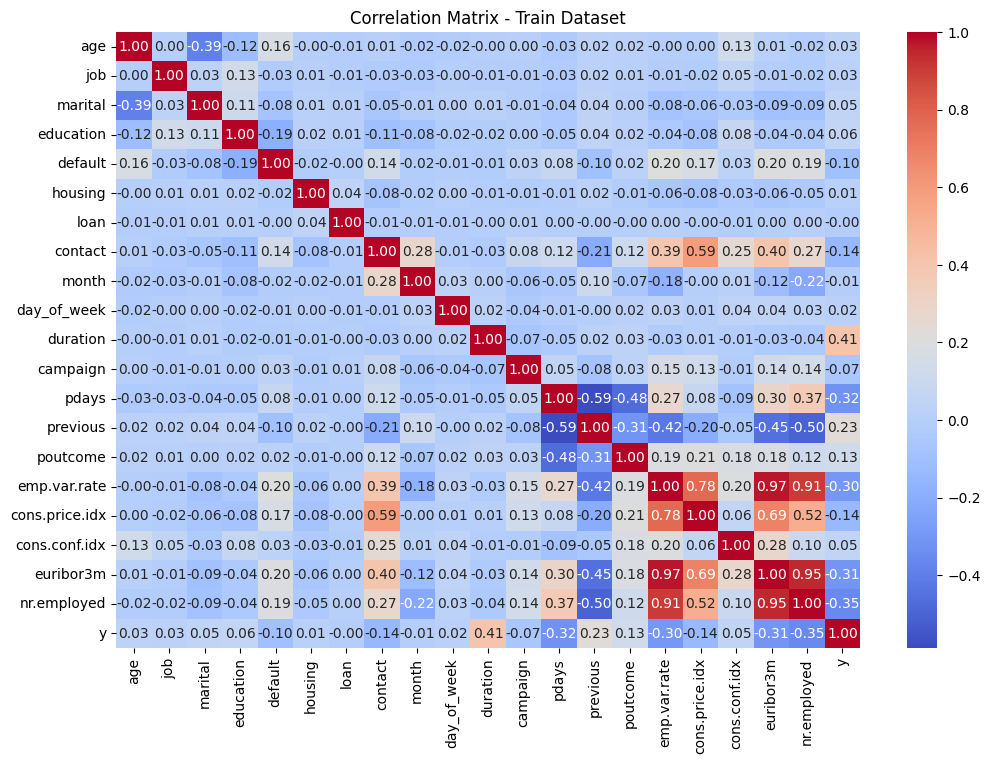

In [ ]:
# plotting the correlation matrix for all columns in the train dataset
train_corr_matrix = train_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(train_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Matrix - Train Dataset')
plt.show()

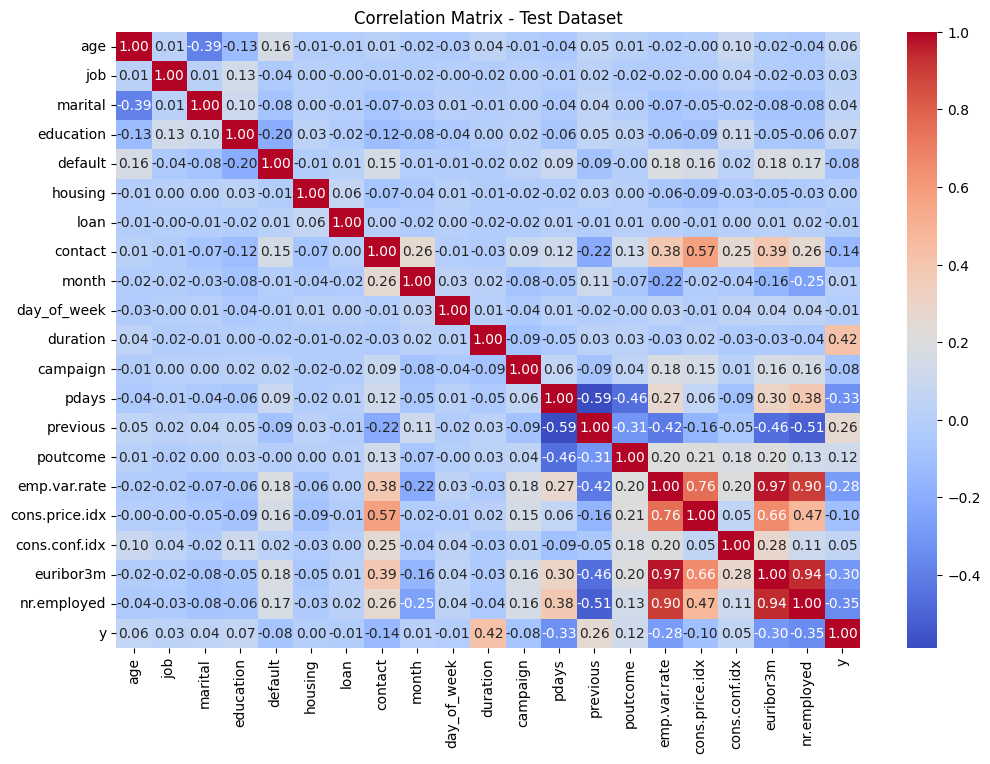

In [ ]:
# plotting the correlation matrix for all columns in the test dataset
test_corr_matrix = test_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(test_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Matrix - Test Dataset')
plt.show()

In [ ]:
# shuffling all the data in the datasets and splitting the data into independent and dependent variables for both datasets

from sklearn.utils import shuffle

train_df = shuffle(train_df).reset_index(drop = True)
test_df = shuffle(test_df).reset_index(drop = True)

x_train = train_df.iloc[:,:-1]
y_train = train_df.iloc[:,-1]

x_test = test_df.iloc[:,:-1]
y_test = test_df.iloc[:,-1]

**Feature Importance**

In [ ]:
# feature importance using random forest classifier

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(x_train, y_train)

importances = rf.feature_importances_
feature_names = x_train.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Rank features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False).reset_index(drop = True)
feature_importance.head(10)

,Feature,Importance
0,duration,0.320029
1,euribor3m,0.108615
2,age,0.092020
3,nr.employed,0.062774
4,job,0.048479
5,education,0.043213
6,campaign,0.041493
7,day_of_week,0.040068
8,pdays,0.033518
9,poutcome,0.030307


In [ ]:
# feature importance using selectkbest and f-test scores

from sklearn.feature_selection import SelectKBest, f_classif

best_features = SelectKBest(score_func = f_classif, k = 10)
fit = best_features.fit(x_train, y_train)

# Get the scores of the features
feature_scores = pd.DataFrame({'Feature': feature_names, 'Score': fit.scores_})
feature_scores = feature_scores.sort_values(by='Score', ascending=False).reset_index(drop = True)
feature_scores.head(10)

,Feature,Score
0,duration,8094.101634
1,nr.employed,5926.610646
2,pdays,4861.173272
3,euribor3m,4309.479048
4,emp.var.rate,4023.829925
5,previous,2304.257088
6,contact,881.707070
7,cons.price.idx,778.589786
8,poutcome,705.678164
9,default,410.590785


In [ ]:
# fidning the threshold using median to select the best features 

fi_columns = feature_importance['Feature'].values
fi_importances = feature_importance['Importance'].values
fi_threshold = feature_importance['Importance'].median()
fi_selected_features = []

for i in range(len(feature_importance)):
    if fi_importances[i] >= fi_threshold:
        fi_selected_features.append(fi_columns[i])

fs_columns = feature_scores['Feature'].values
f_scores = feature_scores['Score'].values
fs_threshold = feature_scores['Score'].median()
fs_selected_features = []

for i in range(len(feature_scores)):
    if f_scores[i] >= fs_threshold:
        fs_selected_features.append(fs_columns[i])

print(len(fi_selected_features))
print(len(fs_selected_features))

10
10


In [ ]:
# using correlation matrix to find the best features using median as threshold

y_corr = abs(train_corr_matrix['y'].values)
y_corr_cols = train_corr_matrix.index.to_numpy()
y_corr_threshold = train_corr_matrix['y'].median()
corr_selected_features = []

for i in range(len(y_corr)):
    if y_corr[i] >= y_corr_threshold:
        corr_selected_features.append(y_corr_cols[i])

len(corr_selected_features)

19

In [ ]:
# train_corr_matrix

In [ ]:
# selecting the best features for model training

columns_selected = set(fs_selected_features) & set(fi_selected_features) & set(corr_selected_features)
columns_selected = list(columns_selected)
columns_selected

['nr.employed', 'pdays', 'poutcome', 'euribor3m', 'duration']

In [ ]:
x_train = x_train[columns_selected]
x_test = x_test[columns_selected]

**Model Training**

In [ ]:
# splitting the train dataset into 2 parts one for model training and other for evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import metrics

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2, random_state = 42)

In [ ]:
# using logistic regression for model training hypertuning included
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

param_grid_lr = {'C': [0.1, 1, 10, 20], 
                 'penalty': ['l1', 'l2'], 
                 'solver': ['liblinear', 'saga']}

grid_search_lr = GridSearchCV(lr, param_grid = param_grid_lr, scoring = 'f1', cv = 5, n_jobs = -1)
grid_search_lr.fit(x_train, y_train)

best_model_lr = grid_search_lr.best_estimator_
best_params_lr = grid_search_lr.best_params_

predictions_lr = best_model_lr.predict(x_val)

best_params_lr

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

In [ ]:
# using random forest classifier for model training hypertuning included
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

param_grid_rf = {'n_estimators': [100, 200, 300, 400],
                 'max_depth': [5, 10, 15, 20]}

grid_search_rf = GridSearchCV(rf, param_grid = param_grid_rf, scoring = 'f1', cv = 5, n_jobs = -1)
grid_search_rf.fit(x_train, y_train)

best_model_rf = grid_search_rf.best_estimator_
best_params_rf = grid_search_rf.best_params_

predictions_rf = best_model_rf.predict(x_val)

best_params_rf

{'max_depth': 10, 'n_estimators': 200}

In [ ]:
# using xgboost classifier for model training hypertuning included
from xgboost import XGBClassifier

xgb = XGBClassifier()

param_grid_xg = {'max_depth': [4, 8, 12],
                 'n_estimators': [100, 200, 300, 400],
                 'learning_rate': [0.1, 0.05, 0.01]}

grid_search_xg = GridSearchCV(xgb, param_grid = param_grid_xg, scoring = 'f1', cv = 5, n_jobs = -1)

grid_search_xg.fit(x_train, y_train)

best_model_xg = grid_search_xg.best_estimator_
best_params_xg = grid_search_xg.best_params_

predictions_xg = best_model_xg.predict(x_val)

best_params_xg

{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}

In [ ]:
# using neural networks for model training hypertuning included

from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(max_iter = 100)

param_grid_nn = {'hidden_layer_sizes': [(50, 50), (100, 50), (100,100)],
                 'activation': ['tanh', 'relu'],
                 'solver': ['adam', 'sgd'],
                 'alpha': [0.0001, 0.001],
                 'learning_rate': ['adaptive'],
                 'learning_rate_init': [0.01, 0.1]}

grid_search_nn = GridSearchCV(nn, param_grid = param_grid_nn, scoring = 'f1', cv = 5, n_jobs = -1, verbose = 2)
grid_search_nn.fit(x_train, y_train)

best_model_nn = grid_search_nn.best_estimator_
best_params_nn = grid_search_nn.best_params_

predictions_nn = best_model_nn.predict(x_val)

best_params_nn

Fitting 5 folds for each of 48 candidates, totalling 240 fits


{'activation': 'tanh',
 'alpha': 0.0001,
 'hidden_layer_sizes': (100, 100),
 'learning_rate': 'adaptive',
 'learning_rate_init': 0.01,
 'solver': 'adam'}

In [ ]:
# finding accuracy of all the models trained

accuracy_lr = metrics.accuracy_score(y_val, predictions_lr)
accuracy_rf = metrics.accuracy_score(y_val, predictions_rf)
accuracy_xg = metrics.accuracy_score(y_val, predictions_xg)
accuracy_nn = metrics.accuracy_score(y_val, predictions_nn)

accuracy_scores = [accuracy_lr, accuracy_rf, accuracy_xg, accuracy_nn]
accuracy_scores

[0.9082301529497451,
 0.9127215343529983,
 0.9146637533381888,
 0.9089584850691915]

In [ ]:
# finding precision of all the models trained

precision_lr = metrics.precision_score(y_val, predictions_lr)
precision_rf = metrics.precision_score(y_val, predictions_rf)
precision_xg = metrics.precision_score(y_val, predictions_xg)
precision_nn = metrics.precision_score(y_val, predictions_nn)

precision_scores = [precision_lr, precision_rf, precision_xg, precision_nn]
precision_scores

[0.6442307692307693,
 0.6261808367071525,
 0.6407766990291263,
 0.6529411764705882]

In [ ]:
# finding recall of all the models trained

recall_lr = metrics.recall_score(y_val, predictions_lr)
recall_rf = metrics.recall_score(y_val, predictions_rf)
recall_xg = metrics.recall_score(y_val, predictions_xg)
recall_nn = metrics.recall_score(y_val, predictions_nn)

recall_scores = [recall_lr, recall_rf, recall_xg, recall_nn]
recall_scores

[0.369757174392936, 0.5121412803532008, 0.5099337748344371, 0.3675496688741722]

In [ ]:
# finding f1 score of all the models trained

f1_lr = metrics.f1_score(y_val, predictions_lr)
f1_rf = metrics.f1_score(y_val, predictions_rf)
f1_xg = metrics.f1_score(y_val, predictions_xg)
f1_nn = metrics.f1_score(y_val, predictions_nn)

f1_scores = [f1_lr, f1_rf, f1_xg, f1_nn]
f1_scores

[0.46984572230014027,
 0.5634486945962356,
 0.5679164105716041,
 0.4703389830508475]

In [ ]:
# finding roc auc score of all the models trained

roc_lr = metrics.roc_auc_score(y_val, predictions_lr)
roc_rf = metrics.roc_auc_score(y_val, predictions_rf)
roc_xg = metrics.roc_auc_score(y_val, predictions_xg)
roc_nn = metrics.roc_auc_score(y_val, predictions_nn)

roc_scores = [roc_lr, roc_rf, roc_xg, roc_nn]
roc_scores

[0.6722626570273463,
 0.7371808420314833,
 0.7373045851804482,
 0.6717044580050076]

In [ ]:
# creating dataframe for scores

models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network']

scores_df = pd.DataFrame()
scores_df['model'] = models
scores_df['accuracy'] = accuracy_scores
scores_df['precision'] = precision_scores
scores_df['recall'] = recall_scores
scores_df['f1'] = f1_scores
scores_df['roc_auc'] = roc_scores

scores_df = scores_df.sort_values(by = ['f1'], ascending = False).reset_index(drop = True)
scores_df

,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.914664,0.640777,0.509934,0.567916,0.737305
1,Random Forest,0.912722,0.626181,0.512141,0.563449,0.737181
2,Logistic Regression,0.908230,0.644231,0.369757,0.469846,0.672263
3,Neural Network,0.908958,0.652941,0.367550,0.470339,0.671704


In [ ]:
# selecting the model with highest accuracy score
selected_model = scores_df['model'].values
selected_model = selected_model[0]
selected_model

'XGBoost'

In [ ]:
if selected_model == 'Linear Regression':
    model = best_model_lr
elif selected_model == 'Random Forest':
    model = best_model_rf
elif selected_model == 'XGBoost':
    model = best_model_xg
else:
    model = best_model_nn

model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
# predicting the values for test dataset

predictions = model.predict(x_test)

accuracy = metrics.accuracy_score(y_test, predictions)
print(f'Accuracy Score is: {accuracy}')

precision = metrics.precision_score(y_test, predictions)
print(f'Precision Score is: {precision}')

recall = metrics.recall_score(y_test, predictions)
print(f'Recall Score is: {recall}')

f1 = metrics.f1_score(y_test, predictions)
print(f'F1 Score is: {f1}')

roc = metrics.roc_auc_score(y_test, predictions)
print(f'AUC ROC Score is: {roc}')

Accuracy Score is: 0.9235251274581209
Precision Score is: 0.6857923497267759
Recall Score is: 0.5565410199556541
F1 Score is: 0.6144430844553244
AUC ROC Score is: 0.7625943922024726


In [ ]:
matrix = metrics.confusion_matrix(y_test, predictions)
matrix = pd.DataFrame(matrix, 
                      columns = ['Predicted Negatives', 'Predicted Positives'], 
                      index = ['Actual Negatives', 'Actual Positives'])

matrix

,Predicted Negatives,Predicted Positives
Actual Negatives,3553,115
Actual Positives,200,251
